In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
print("Loading the multi-stressor dataset...")
df = pd.read_csv('dataset_with_oil.csv')

# Verify the new anthropogenic columns are present
print(f"Dataset shape: {df.shape}")
print("Features included in this model:")
print(list(df.columns))

Loading the multi-stressor dataset...
Dataset shape: (32716, 13)
Features included in this model:
['Latitude_Degrees', 'Longitude_Degrees', 'ClimSST', 'Temperature_Mean', 'Depth_m', 'Windspeed', 'SSTA', 'Distance_to_Plastic_km', 'Nearest_Plastic_Weight_kg', 'Is_Heavily_Polluted', 'Distance_to_Oil_Spill_km', 'Nearest_Oil_Spill_Gallons', 'Percent_Bleaching']


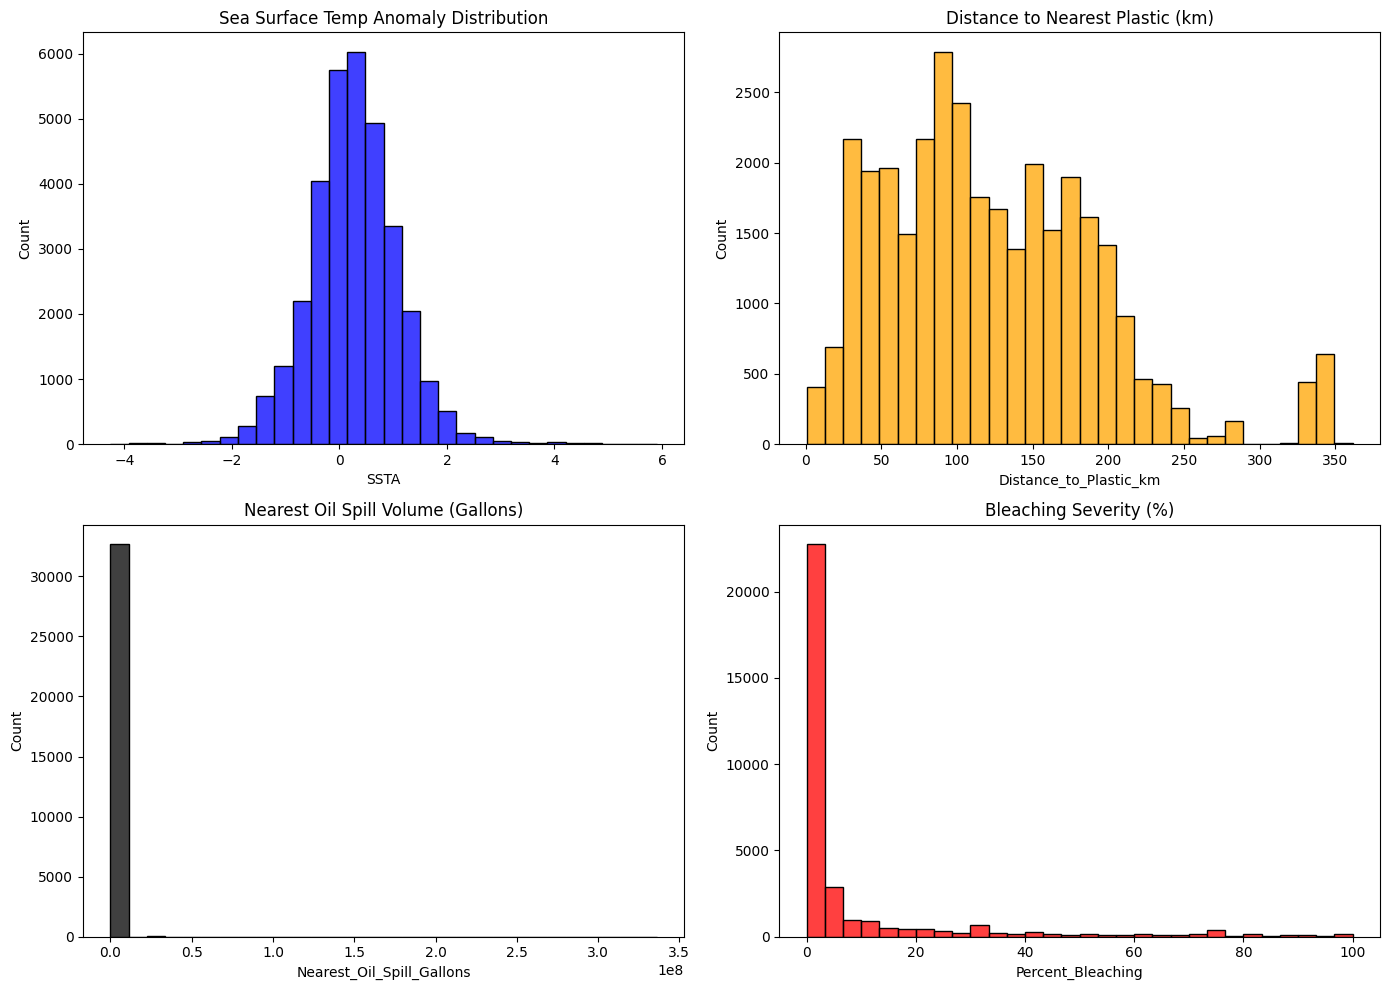

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for the multi-stressor variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df['SSTA'], bins=30, ax=axes[0,0], color='blue').set_title('Sea Surface Temp Anomaly Distribution')
sns.histplot(df['Distance_to_Plastic_km'], bins=30, ax=axes[0,1], color='orange').set_title('Distance to Nearest Plastic (km)')
sns.histplot(df['Nearest_Oil_Spill_Gallons'], bins=30, ax=axes[1,0], color='black').set_title('Nearest Oil Spill Volume (Gallons)')
sns.histplot(df['Percent_Bleaching'], bins=30, ax=axes[1,1], color='red').set_title('Bleaching Severity (%)')
plt.tight_layout()
plt.show()

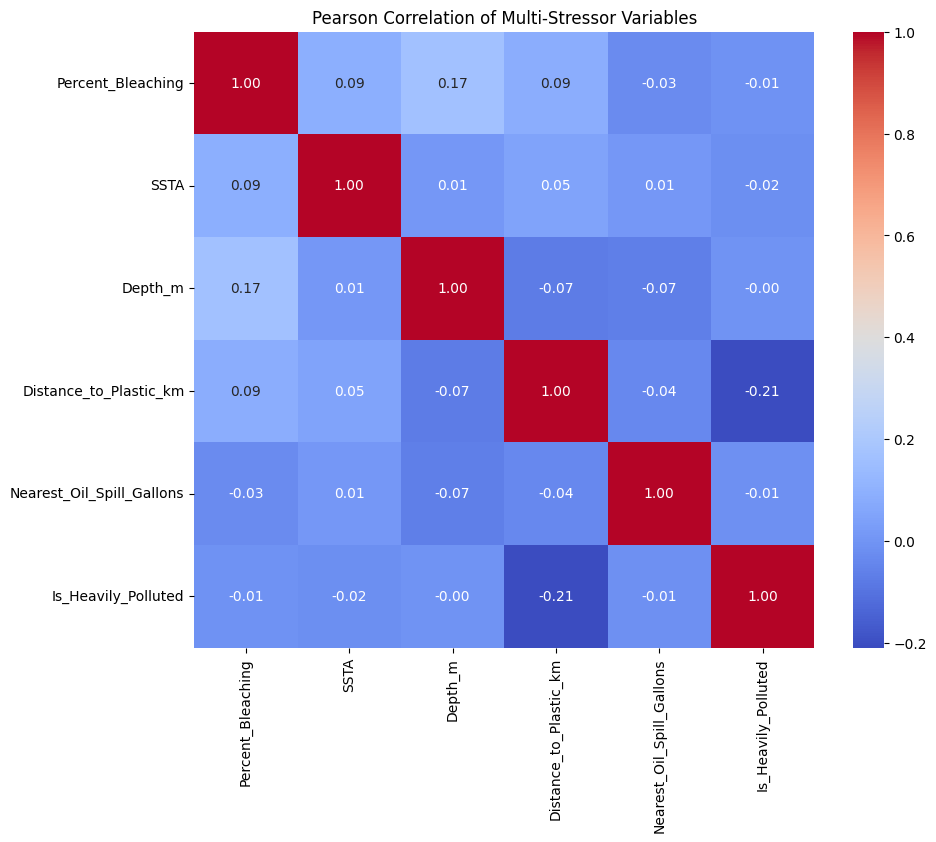

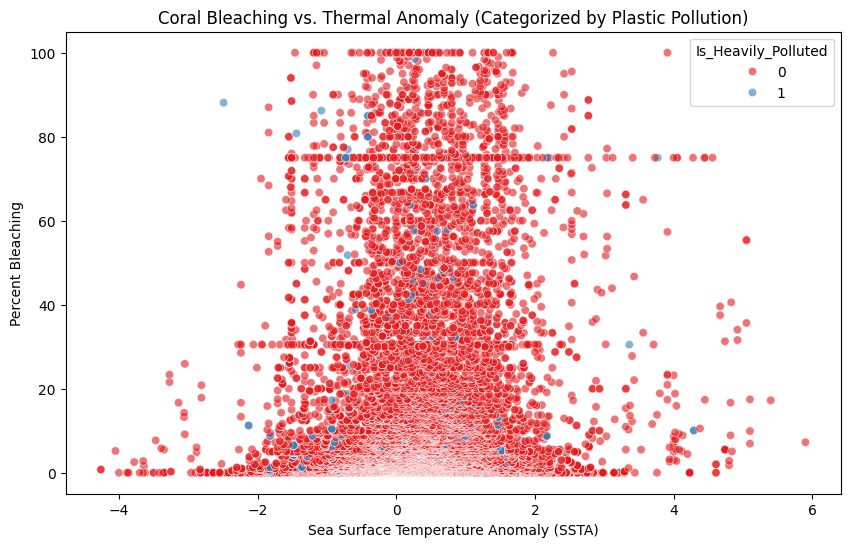

In [14]:
# 1. Pearson Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_cols = ['Percent_Bleaching', 'SSTA', 'Depth_m', 'Distance_to_Plastic_km', 'Nearest_Oil_Spill_Gallons', 'Is_Heavily_Polluted']
sns.heatmap(df[correlation_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Pearson Correlation of Multi-Stressor Variables")
plt.show()

# 2. Scatter Plot: Temperature vs Bleaching (Colored by Pollution)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='SSTA', y='Percent_Bleaching', hue='Is_Heavily_Polluted', palette='Set1', alpha=0.6)
plt.title("Coral Bleaching vs. Thermal Anomaly (Categorized by Plastic Pollution)")
plt.xlabel("Sea Surface Temperature Anomaly (SSTA)")
plt.ylabel("Percent Bleaching")
plt.show()

In [9]:
# [Cell 3] Separate the independent variables (X) from the dependent variable (y)
X = df.drop(columns=['Percent_Bleaching'])
y = df['Percent_Bleaching']

# Split the data into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape[0]} rows.")
print(f"Testing data size: {X_test.shape[0]} rows.")

Training data size: 26172 rows.
Testing data size: 6544 rows.


In [10]:
# [Cell 4] Standardize the features
# This step is mathematically critical. It prevents the massive numbers in the 
# 'Nearest_Oil_Spill_Gallons' column from dominating the smaller numbers in 'SSTA' or 'Depth_m'.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete. All variables are now on a standardized mathematical plane.")

Feature scaling complete. All variables are now on a standardized mathematical plane.


In [11]:
# [Cell 5] Initialize and train the regression models
print("Initializing models...")
knn = KNeighborsRegressor(n_neighbors=5)
rf = RandomForestRegressor(n_estimators=100, random_state=42)

print("Training K-Nearest Neighbors...")
knn.fit(X_train_scaled, y_train)

print("Training Random Forest... (This may take a moment)")
rf.fit(X_train_scaled, y_train)

print("Model training complete.")

Initializing models...
Training K-Nearest Neighbors...
Training Random Forest... (This may take a moment)
Model training complete.


In [12]:
# [Cell 6] Generate predictions and evaluate performance using standard metrics
knn_preds = knn.predict(X_test_scaled)
rf_preds = rf.predict(X_test_scaled)

def print_evaluation_metrics(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"=== {model_name} ===")
    print(f"Mean Absolute Error (MAE): {mae:.2f}%")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}%")
    print(f"R-Squared (R²): {r2:.4f}\n")

# Output the final results
print_evaluation_metrics("K-Nearest Neighbors (KNN)", y_test, knn_preds)
print_evaluation_metrics("Random Forest (RF)", y_test, rf_preds)

=== K-Nearest Neighbors (KNN) ===
Mean Absolute Error (MAE): 6.40%
Root Mean Squared Error (RMSE): 13.25%
R-Squared (R²): 0.4440

=== Random Forest (RF) ===
Mean Absolute Error (MAE): 4.44%
Root Mean Squared Error (RMSE): 10.12%
R-Squared (R²): 0.6760

